# 🎯 Régression, Classification — Cross-Validation & GridSearchCV

Notebook **Wiki technique + cheat-sheet** : un panorama complet de la **validation croisée**
et de la **recherche d'hyperparamètres** (`GridSearchCV`, `RandomizedSearchCV`, Halving, hyperopt,
Optuna) appliquées à tout le **zoo scikit-learn** — régression, clustering, classification.

Fil rouge : **choisir un modèle, le régler sans tricher, et lire les métriques par paramètre ET
par fold**. Pour chaque modèle on suit le même protocole en 3 temps :

1. **Baseline** — un `fit` simple sur un split train/test, pour avoir un ordre de grandeur.
2. **Cross-validation** (`cross_validate`) — une estimation robuste, *fold par fold*.
3. **GridSearchCV** — recherche du meilleur hyperparamètre, avec inspection de `cv_results_`.

> Code typé, exécuté de bout en bout, reproductible (`seed = 42`). Datasets chargés
> programmatiquement (synthétiques `make_*` pour les walkthroughs, California Housing + Titanic
> pour le bench réel).

On centralise tous les imports et deux fonctions utilitaires (`print_regression_grid`,
`print_classif_grid`) qui factorisent l'affichage détaillé d'un `GridSearchCV` — réutilisables
telles quelles dans un autre projet.

In [ ]:
from __future__ import annotations

import re
import warnings

import matplotlib

matplotlib.use("Agg")  # backend non interactif (sandbox / CI)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from numpy import arange

from sklearn.datasets import (
    fetch_california_housing,
    make_blobs,
    make_regression,
)
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedKFold,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")  # silence les FutureWarning/ConvergenceWarning bruyants
RANDOM_STATE = 42


def print_regression_grid(results: GridSearchCV, param_key: str) -> None:
    """Affiche le détail d'un GridSearchCV de régression (scoring MSE + MAE).

    Args:
        results: l'objet `GridSearchCV` déjà `fit`.
        param_key: nom de la clé de paramètre à afficher (ex. 'param_alpha').
    """
    cv = results.cv_results_
    print("Paramètres testés :", list(cv[param_key]))
    print("Mean Squared Error :", np.round(-cv["mean_test_neg_mean_squared_error"], 3))
    print("Mean Absolute Error:", np.round(-cv["mean_test_neg_mean_absolute_error"], 3))
    mse_folds = [-v for k, v in cv.items() if re.match(r"split\d+_test_neg_mean_squared_error", k)]
    print("MSE par fold       :", [np.round(f, 2) for f in mse_folds])
    print(f"Best MSE: {-results.best_score_:.3f} | Best params: {results.best_params_}")


def print_classif_grid(results: GridSearchCV, param_key: str) -> None:
    """Affiche le détail d'un GridSearchCV de classification (scoring f1 + accuracy).

    Args:
        results: l'objet `GridSearchCV` déjà `fit`.
        param_key: nom de la clé de paramètre à afficher (ex. 'param_n_neighbors').
    """
    cv = results.cv_results_
    print("Paramètres testés :", list(cv[param_key]))
    print("F1 (weighted)     :", np.round(cv["mean_test_f1_weighted"], 3))
    print("Accuracy          :", np.round(cv["mean_test_accuracy"], 3))
    f1_folds = [v for k, v in cv.items() if re.match(r"split\d+_test_f1_weighted", k)]
    print("F1 par fold       :", [np.round(f, 2) for f in f1_folds])
    best_idx = int(np.argmax(cv["mean_test_f1_weighted"]))
    print(f"Best F1: {cv['mean_test_f1_weighted'][best_idx]:.3f} | "
          f"Best {param_key}: {cv[param_key][best_idx]}")


print("Setup OK — seed =", RANDOM_STATE)

## 1. La cross-validation : pourquoi et comment

Évaluer un modèle sur les mêmes données qui l'ont entraîné **surestime** sa performance.
On cherche l'**erreur de généralisation** $R(f) = \mathbb{E}_{(x,y)}[\,\ell(f(x), y)\,]$, que la
**$k$-fold cross-validation** estime sans biais optimiste : on découpe les données en $k$ plis,
on entraîne sur $k-1$ plis et on teste sur le pli restant, puis on moyenne :

$$\hat{R}_{CV} = \frac{1}{k} \sum_{i=1}^{k} \frac{1}{|D_i|} \sum_{(x,y)\in D_i} \ell\big(f^{(-i)}(x),\, y\big)$$

Le choix de $k$ arbitre le **compromis biais-variance** de l'estimation : $k$ petit (ex. 2) →
estimation biaisée (peu de données d'entraînement par pli) ; $k$ grand (ex. LOO, $k=n$) → faible
biais mais **forte variance** et coût élevé. En pratique $k \in \{5, 10\}$ est le standard.

| Splitter | Quand l'utiliser |
|---|---|
| **KFold** | Régression / classification équilibrée |
| **StratifiedKFold** | Classification — préserve la proportion de classes par pli |
| **GroupKFold** | Observations groupées (plusieurs lignes par patient/utilisateur) |
| **TimeSeriesSplit** | Séries temporelles — **jamais** de `shuffle` |
| **RepeatedKFold** | Répète le découpage pour réduire la variance de l'estimation |
| **LeaveOneOut** | Très petits jeux de données |

Le schéma ci-dessous illustre le découpage en plis (un pli de test, le reste en entraînement,
qui tourne) :

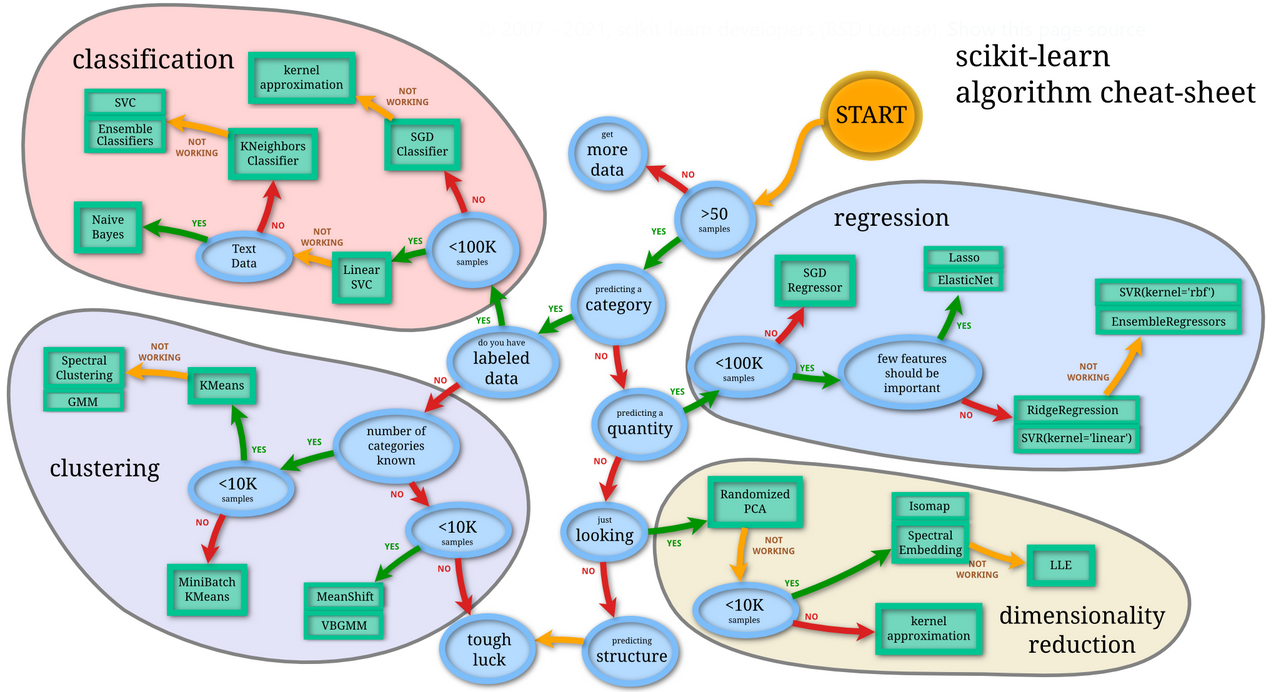

Vérifions concrètement la différence entre `KFold` et `StratifiedKFold` sur une cible
**déséquilibrée** : seul le second garde la proportion de positifs stable d'un pli à l'autre.

In [ ]:
# Démonstration des schémas de découpage : tailles de folds produites par chaque splitter.
from sklearn.model_selection import KFold

X_demo = np.arange(20).reshape(-1, 1)
y_demo = np.array([0] * 14 + [1] * 6)  # déséquilibré pour illustrer la stratification

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("KFold — proportion de positifs par pli de test :")
print([round(y_demo[test].mean(), 2) for _, test in kf.split(X_demo, y_demo)])
print("StratifiedKFold — proportion de positifs par pli de test (préservée) :")
print([round(y_demo[test].mean(), 2) for _, test in skf.split(X_demo, y_demo)])

`StratifiedKFold` maintient ~30 % de positifs dans chaque pli, alors que `KFold` laisse la
proportion fluctuer — d'où des scores plus bruités en classification déséquilibrée.

## 2. Stratégies de recherche d'hyperparamètres

Régler les hyperparamètres, c'est explorer un espace $\Lambda = \Lambda_1 \times \dots \times
\Lambda_d$. Le coût d'une recherche exhaustive **explose** combinatoirement : pour $d$
hyperparamètres à $m$ valeurs chacun et une CV à $k$ plis, c'est $k \cdot m^d$ entraînements.

| Méthode | Idée | Quand |
|---|---|---|
| **GridSearchCV** | Toutes les combinaisons | Petite grille (< ~100 combos) |
| **RandomizedSearchCV** | $n$ tirages aléatoires dans des distributions | Grande grille, budget fixe |
| **HalvingGridSearchCV / HalvingRandomSearchCV** | *Successive halving* : élimine tôt les mauvais sur peu de données | Grande grille, gain de temps |
| **BayesSearchCV** (`scikit-optimize`) | Optimisation bayésienne (surrogate model) | Évaluations coûteuses |
| **hyperopt / Optuna** | TPE, CMA-ES, *pruners*, distribué | **Standard 2026** pour la recherche sérieuse |

Random search bat souvent grid search à budget égal : si seuls quelques hyperparamètres comptent
vraiment, le tirage aléatoire couvre mieux leurs dimensions utiles (Bergstra & Bengio, 2012).

## 3. Pipeline + ColumnTransformer : éviter la fuite de données

**Toujours** encapsuler `preprocessing + modèle` dans une `Pipeline`. Sinon, un `StandardScaler`
(ou un imputeur) `fit` sur l'ensemble des données **voit** le test pendant la CV → **fuite**
(*data leakage*) et score optimiste. Dans une `Pipeline`, chaque pli ré-ajuste le preprocessing
uniquement sur sa partie entraînement.

Pour des features **mixtes** (numériques + catégorielles), `ColumnTransformer` applique un
traitement différent par groupe de colonnes. Ci-dessous, le jeu **Titanic** qui servira aussi
au bench et au tuning plus loin.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

titanic = __import__("seaborn").load_dataset("titanic").dropna(subset=["embarked"])
num_cols = ["age", "fare", "sibsp", "parch"]
cat_cols = ["pclass", "sex", "embarked"]
X_titanic = titanic[num_cols + cat_cols]
y_titanic = titanic["survived"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
pipe = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(max_iter=1000))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
auc = cross_val_score(pipe, X_titanic, y_titanic, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"LogReg (pipeline) CV ROC-AUC = {auc.mean():.4f} ± {auc.std():.4f}")

Le `cross_val_score` renvoie une AUC `mean ± std` honnête : tout le preprocessing est refait
dans chaque pli. C'est l'objet `pipe` (et son `preprocessor`) qu'on réutilisera tel quel.

## 4. Régression

On démarre le walkthrough cœur sur un jeu **synthétique** `make_regression` (1000 points,
5 features informatives, bruit léger), standardisé et splitté. Métriques : **MSE** et **MAE**.

Pour chaque régresseur : baseline → `cross_validate` (RepeatedKFold) → `GridSearchCV` avec lecture
de `cv_results_` (moyenne par paramètre, détail par pli, meilleur réglage).

In [ ]:
# --- Régression : jeu synthétique reproductible ---
X, y = make_regression(n_samples=1000, n_features=5, noise=1, random_state=RANDOM_STATE)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
print("Régression — X:", X.shape, "| train:", X_train.shape, "test:", X_test.shape)

### Régression Lasso

La **régression Lasso** est une régression linéaire régularisée par une pénalité **L1** :

$$\hat{\beta} = \arg\min_{\beta}\; \tfrac{1}{2n}\lVert y - X\beta \rVert_2^2 \;+\; \alpha \lVert \beta \rVert_1$$

La norme $\lVert\beta\rVert_1 = \sum_j |\beta_j|$ pousse certains coefficients **exactement à zéro** →
**sélection automatique de variables**. Le paramètre $\alpha$ contrôle la force de la pénalité
(plus il est grand, plus le modèle est creux).

In [ ]:
# Lasso — baseline
from sklearn.linear_model import Lasso

model = Lasso(alpha=1.0)
model.fit(X_train, y_train)
print("Test MSE : %.2f" % mean_squared_error(y_test, model.predict(X_test)))
print("Test MAE : %.2f" % mean_absolute_error(y_test, model.predict(X_test)))

En cross-validation, MSE et MAE sont reportés pli par pli (variance de l'estimation visible) :

In [ ]:
# Lasso — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(Lasso(alpha=1.0), X, y, cv=CV,
                        scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                        return_train_score=True)
print("MSE par fold :", np.round(-scores["test_neg_mean_squared_error"], 2))
print("MAE par fold :", np.round(-scores["test_neg_mean_absolute_error"], 2))

`GridSearchCV` balaie $\alpha$. On inspecte `cv_results_` : moyenne par paramètre, détail par
pli, et meilleur $\alpha$ (refit sur le MSE) :

In [ ]:
# Lasso — GridSearchCV sur alpha
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"alpha": arange(0.01, 0.1, 0.03)}
search = GridSearchCV(Lasso(), grid,
                      scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                      cv=CV, refit="neg_mean_squared_error")
results = search.fit(X, y)
print_regression_grid(results, "param_alpha")

Le meilleur $\alpha$ minimise le MSE moyen ; un $\alpha$ trop grand sous-ajuste (biais).

### Arbre de décision (régression)

Un **arbre de régression** (CART) partitionne récursivement l'espace des features en régions, et
prédit la **moyenne** de $y$ dans chaque feuille. Découpages choisis pour minimiser la variance
intra-région. Très expressif (donc sujet au surapprentissage), non linéaire, sans mise à l'échelle.

In [ ]:
# Decision Tree Regressor — baseline
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=RANDOM_STATE)
model.fit(X_train, y_train)
print("Test MSE : %.2f" % mean_squared_error(y_test, model.predict(X_test)))
print("Test MAE : %.2f" % mean_absolute_error(y_test, model.predict(X_test)))

En cross-validation :

In [ ]:
# Decision Tree Regressor — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(DecisionTreeRegressor(random_state=RANDOM_STATE), X, y, cv=CV,
                        scoring=("neg_mean_squared_error", "neg_mean_absolute_error"))
print("MSE par fold :", np.round(-scores["test_neg_mean_squared_error"], 2))
print("MAE par fold :", np.round(-scores["test_neg_mean_absolute_error"], 2))

`GridSearchCV` sur `max_features` (nombre de features candidates à chaque split) :

In [ ]:
# Decision Tree Regressor — GridSearchCV sur max_features
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"max_features": [1.0, "sqrt", "log2"]}
search = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE), grid,
                      scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                      cv=CV, refit="neg_mean_squared_error")
results = search.fit(X, y)
print_regression_grid(results, "param_max_features")

### Stochastic Gradient Descent (régression)

`SGDRegressor` ajuste un modèle linéaire par **descente de gradient stochastique** : à chaque
itération, les poids sont mis à jour sur **un** échantillon (ou un mini-batch),
$\beta \leftarrow \beta - \eta\, \nabla_\beta \ell(\beta; x_i, y_i)$. Idéal pour les très gros
jeux de données (apprentissage *out-of-core*). Sensible à l'échelle → standardisation requise.

In [ ]:
# SGD Regressor — baseline
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
print("Test MSE : %.2f" % mean_squared_error(y_test, model.predict(X_test)))
print("Test MAE : %.2f" % mean_absolute_error(y_test, model.predict(X_test)))

En cross-validation :

In [ ]:
# SGD Regressor — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(SGDRegressor(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE), X, y, cv=CV,
                        scoring=("neg_mean_squared_error", "neg_mean_absolute_error"))
print("MSE par fold :", np.round(-scores["test_neg_mean_squared_error"], 2))
print("MAE par fold :", np.round(-scores["test_neg_mean_absolute_error"], 2))

`GridSearchCV` sur le type de pénalité (`l2`, `l1`, `elasticnet`) :

In [ ]:
# SGD Regressor — GridSearchCV sur penalty
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"penalty": ["l2", "l1", "elasticnet"]}
search = GridSearchCV(SGDRegressor(tol=1e-3, random_state=RANDOM_STATE), grid,
                      scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                      cv=CV, refit="neg_mean_squared_error")
results = search.fit(X, y)
print_regression_grid(results, "param_penalty")

### Support Vector Regression (SVR)

La **SVR** cherche une fonction qui s'écarte des cibles d'au plus $\varepsilon$ (tube
d'insensibilité) tout en restant la plus *plate* possible. Le **kernel trick** projette
implicitement les données dans un espace de plus grande dimension (noyau `rbf`, `poly`…), ce qui
permet de capturer des relations **non linéaires** sans calculer explicitement la projection.

In [ ]:
# SVR — baseline
from sklearn.svm import SVR

model = SVR()
model.fit(X_train, y_train)
print("Test MSE : %.2f" % mean_squared_error(y_test, model.predict(X_test)))
print("Test MAE : %.2f" % mean_absolute_error(y_test, model.predict(X_test)))

En cross-validation :

In [ ]:
# SVR — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(SVR(), X, y, cv=CV,
                        scoring=("neg_mean_squared_error", "neg_mean_absolute_error"))
print("MSE par fold :", np.round(-scores["test_neg_mean_squared_error"], 2))
print("MAE par fold :", np.round(-scores["test_neg_mean_absolute_error"], 2))

`GridSearchCV` sur le noyau :

In [ ]:
# SVR — GridSearchCV sur le noyau
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"kernel": ["linear", "poly", "rbf", "sigmoid"]}
search = GridSearchCV(SVR(), grid,
                      scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                      cv=CV, refit="neg_mean_squared_error")
results = search.fit(X, y)
print_regression_grid(results, "param_kernel")

### Random Forest (régression)

Une **forêt aléatoire** est un ensemble d'arbres entraînés sur des échantillons **bootstrap** et
des sous-ensembles aléatoires de features (**bagging** + *feature subsampling*). La prédiction est
la **moyenne** des arbres → variance réduite, robustesse au surapprentissage.

In [ ]:
# Random Forest Regressor — baseline
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=RANDOM_STATE)
model.fit(X_train, y_train)
print("Test MSE : %.2f" % mean_squared_error(y_test, model.predict(X_test)))
print("Test MAE : %.2f" % mean_absolute_error(y_test, model.predict(X_test)))

En cross-validation :

In [ ]:
# Random Forest Regressor — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(RandomForestRegressor(random_state=RANDOM_STATE), X, y, cv=CV,
                        scoring=("neg_mean_squared_error", "neg_mean_absolute_error"))
print("MSE par fold :", np.round(-scores["test_neg_mean_squared_error"], 2))
print("MAE par fold :", np.round(-scores["test_neg_mean_absolute_error"], 2))

`GridSearchCV` sur le critère de split :

In [ ]:
# Random Forest Regressor — GridSearchCV sur le critère
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"criterion": ["squared_error", "absolute_error", "friedman_mse"]}
search = GridSearchCV(RandomForestRegressor(n_estimators=50, random_state=RANDOM_STATE), grid,
                      scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                      cv=CV, refit="neg_mean_squared_error")
results = search.fit(X, y)
print_regression_grid(results, "param_criterion")

### Gradient Boosting (régression)

Le **gradient boosting** construit les arbres **séquentiellement** : chaque nouvel arbre corrige
les erreurs résiduelles du précédent, en ajustant l'opposé du gradient de la perte,
$F_{m}(x) = F_{m-1}(x) + \nu\, h_m(x)$ (avec $\nu$ le *learning rate*). Très performant mais plus
sensible au réglage que la forêt.

In [ ]:
# Gradient Boosting Regressor — baseline
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                  random_state=RANDOM_STATE)
model.fit(X_train, y_train)
print("Test MSE : %.2f" % mean_squared_error(y_test, model.predict(X_test)))
print("Test MAE : %.2f" % mean_absolute_error(y_test, model.predict(X_test)))

En cross-validation :

In [ ]:
# Gradient Boosting Regressor — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(GradientBoostingRegressor(random_state=RANDOM_STATE), X, y, cv=CV,
                        scoring=("neg_mean_squared_error", "neg_mean_absolute_error"))
print("MSE par fold :", np.round(-scores["test_neg_mean_squared_error"], 2))
print("MAE par fold :", np.round(-scores["test_neg_mean_absolute_error"], 2))

`GridSearchCV` sur la fonction de perte :

In [ ]:
# Gradient Boosting Regressor — GridSearchCV sur la loss
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"loss": ["squared_error", "absolute_error", "huber", "quantile"]}
search = GridSearchCV(GradientBoostingRegressor(random_state=RANDOM_STATE), grid,
                      scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                      cv=CV, refit="neg_mean_squared_error")
results = search.fit(X, y)
print_regression_grid(results, "param_loss")

### AdaBoost (régression)

**AdaBoost** combine des *weak learners* (ici des arbres peu profonds) en **repondérant** à
chaque itération les exemples mal prédits, pour que les modèles suivants se concentrent dessus.
Le réglage clé est la complexité du weak learner (profondeur de l'arbre de base).

In [ ]:
# AdaBoost Regressor — baseline
from sklearn.ensemble import AdaBoostRegressor

estimator = DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE)
model = AdaBoostRegressor(estimator=estimator, random_state=RANDOM_STATE)
model.fit(X_train, y_train)
print("Test MSE : %.2f" % mean_squared_error(y_test, model.predict(X_test)))
print("Test MAE : %.2f" % mean_absolute_error(y_test, model.predict(X_test)))

En cross-validation :

In [ ]:
# AdaBoost Regressor — cross-validation
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
model = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1, random_state=RANDOM_STATE),
                          random_state=RANDOM_STATE)
scores = cross_validate(model, X, y, cv=CV,
                        scoring=("neg_mean_squared_error", "neg_mean_absolute_error"))
print("MSE par fold :", np.round(-scores["test_neg_mean_squared_error"], 2))
print("MAE par fold :", np.round(-scores["test_neg_mean_absolute_error"], 2))

`GridSearchCV` sur la profondeur de l'estimateur de base :

In [ ]:
# AdaBoost Regressor — GridSearchCV sur la profondeur du weak learner
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"estimator": [DecisionTreeRegressor(max_depth=1), DecisionTreeRegressor(max_depth=3),
                      DecisionTreeRegressor(max_depth=5)]}
search = GridSearchCV(AdaBoostRegressor(random_state=RANDOM_STATE), grid,
                      scoring=("neg_mean_squared_error", "neg_mean_absolute_error"),
                      cv=CV, refit="neg_mean_squared_error")
results = search.fit(X, y)
print_regression_grid(results, "param_estimator")

## 5. Clustering

On passe à l'**apprentissage non supervisé** sur des `make_blobs` (3 amas, 10 dimensions).
Métriques :

- **Silhouette** $s = \dfrac{b - a}{\max(a, b)} \in [-1, 1]$ — cohésion intra-cluster $a$ vs
  séparation inter-cluster $b$ ; ne nécessite pas les vrais labels.
- **Adjusted Rand Index (ARI)** — compare le clustering aux vraies classes, **invariant à la
  permutation** des étiquettes (les numéros de cluster sont arbitraires).

In [ ]:
# --- Clustering : blobs synthétiques ---
from sklearn.cluster import DBSCAN, KMeans

Xc, yc = make_blobs(n_samples=1000, centers=3, n_features=10, cluster_std=5,
                    random_state=RANDOM_STATE)
Xc = StandardScaler().fit_transform(Xc)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.20,
                                                        random_state=RANDOM_STATE)
print("Clustering — X:", Xc.shape)

### KMeans

**KMeans** minimise l'**inertie** (somme des distances au carré au centroïde le plus proche) :

$$J = \sum_{i=1}^{n} \min_{\mu_c \in C} \lVert x_i - \mu_c \rVert^2$$

Algorithme itératif (Lloyd) : affecter chaque point au centroïde le plus proche, recalculer les
centroïdes, répéter. On évalue ici par silhouette (non supervisé) et ARI (vs vrais labels).

> *Note de correction vs original* : la version d'origine importait mal `silhouette_score`,
> écrasait `adjusted_rand_score` par sa propre valeur, et faisait un `X.reshape(1,-1)` qui cassait
> la CV. Code réécrit proprement ci-dessous.

In [ ]:
# KMeans — métriques non supervisées (silhouette) et supervisée (ARI, invariante à la permutation)
km = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE)
labels_train = km.fit_predict(Xc_train)
labels_test = km.predict(Xc_test)
print("Silhouette (test)        : %.3f" % silhouette_score(Xc_test, labels_test))
print("Adjusted Rand Index (test): %.3f" % adjusted_rand_score(yc_test, labels_test))

La **méthode du coude** trace l'inertie en fonction de $k$ : on cherche le « coude » où ajouter
un cluster ne réduit plus beaucoup l'inertie (ici autour de $k=3$, le vrai nombre d'amas).

In [ ]:
# KMeans — méthode du coude (inertie vs nombre de clusters)
inerties = []
ks = range(1, 9)
for k in ks:
    inerties.append(KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Xc_train).inertia_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(ks), inerties, "o-")
ax.set_xlabel("k (nombre de clusters)")
ax.set_ylabel("Inertie")
ax.set_title("Méthode du coude — KMeans")
fig.tight_layout()
fig.savefig("scripts/_sandbox/_fig_cv_kmeans_elbow.png", dpi=90)
plt.close(fig)
print("Inerties k=1..8 :", [round(v, 1) for v in inerties])

On peut aussi régler KMeans par `GridSearchCV`, scoré par l'**ARI** (via `make_scorer`, car le
scorer doit être invariant à la permutation des étiquettes) sur le paramètre `algorithm` :

In [ ]:
# KMeans — GridSearchCV sur l'algorithme, scoré par ARI (scorer permutation-invariant)
from sklearn.metrics import make_scorer

ari_scorer = make_scorer(adjusted_rand_score)
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"algorithm": ["lloyd", "elkan"]}
search = GridSearchCV(KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE), grid,
                      scoring=ari_scorer, cv=CV)
results = search.fit(Xc, yc)
print("Algorithmes testés :", list(results.cv_results_["param_algorithm"]))
print("ARI moyen          :", np.round(results.cv_results_["mean_test_score"], 3))
print(f"Best ARI: {results.best_score_:.3f} | Best params: {results.best_params_}")

### DBSCAN

**DBSCAN** regroupe par **densité** : un point est *core* s'il a au moins `min_samples` voisins
dans un rayon $\varepsilon$. Les clusters sont des composantes connexes de points denses ; les
points isolés sont étiquetés **bruit** ($-1$). Avantages : pas besoin de fixer le nombre de
clusters, détecte des formes arbitraires et le bruit. C'est un algorithme **transductif** (pas de
`predict` sur de nouvelles données) → on évalue sur le `fit`.

> *Correction vs original* : `dbscan.score()` n'existe pas et la silhouette était mal calculée.
> On rapporte ici proprement le nombre de clusters, le bruit, et la silhouette hors bruit.

In [ ]:
# DBSCAN — clustering par densité (transductif : pas de predict, on évalue sur le fit)
db = DBSCAN(eps=1.5, min_samples=10)
labels_db = db.fit_predict(Xc)
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_bruit = int((labels_db == -1).sum())
print(f"DBSCAN — clusters trouvés : {n_clusters} | points de bruit : {n_bruit}")
if n_clusters >= 2:
    mask = labels_db != -1
    print("Silhouette (hors bruit) : %.3f" % silhouette_score(Xc[mask], labels_db[mask]))

## 6. Classification

On revient au supervisé avec des `make_blobs` à **3 classes**. La figure ci-dessous (extraite de
la galerie scikit-learn) illustre les **frontières de décision** de différents classifieurs sur
des jeux 2D — utile pour intuiter la géométrie de chaque modèle :

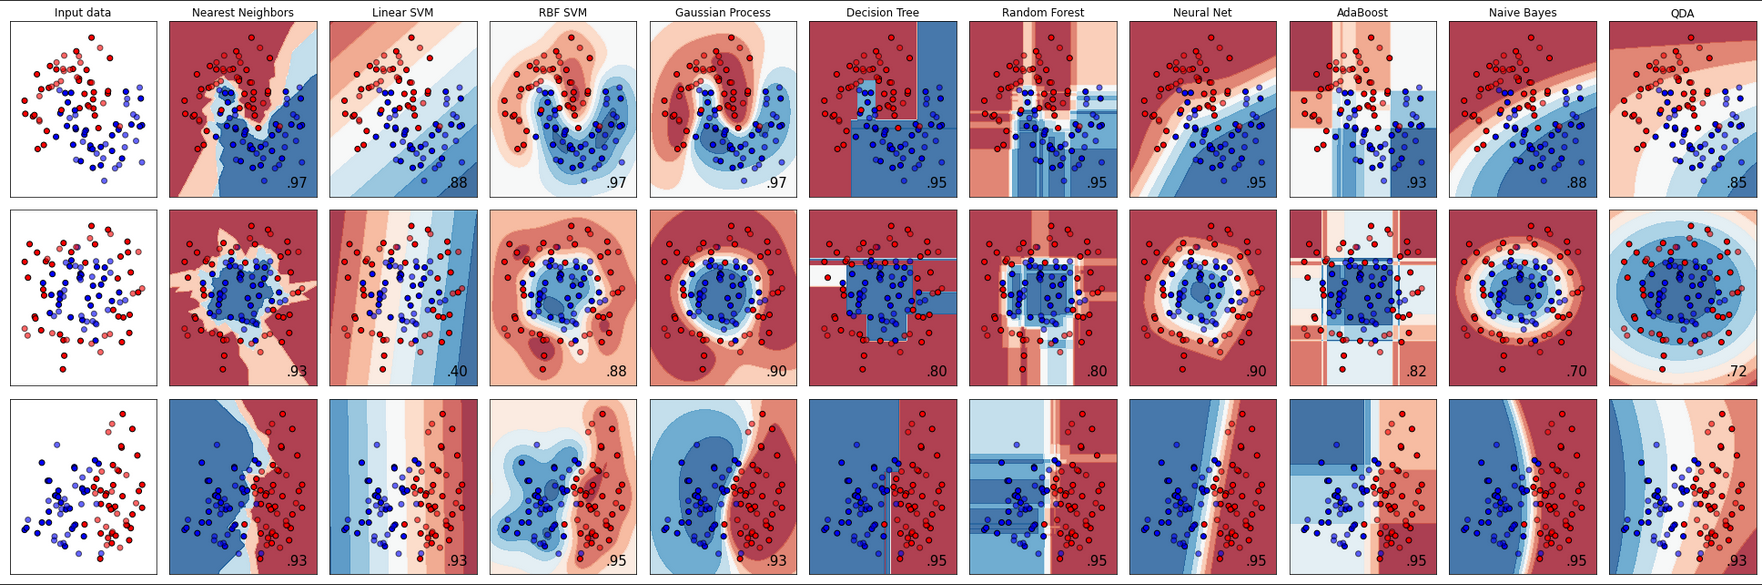

Référence : [comparaison des classifieurs — scikit-learn](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html).
Métriques : **F1** (weighted/macro) et **accuracy**. Même protocole baseline → CV → GridSearch.

In [ ]:
# --- Classification : blobs 3 classes ---
Xk, yk = make_blobs(n_samples=1000, centers=3, cluster_std=2.75, random_state=RANDOM_STATE)
Xk = StandardScaler().fit_transform(Xk)
Xk_train, Xk_test, yk_train, yk_test = train_test_split(Xk, yk, test_size=0.20,
                                                        random_state=RANDOM_STATE)
print("Classification — X:", Xk.shape, "| classes:", np.unique(yk))

### K plus proches voisins (KNN)

**KNN** classe un point par **vote majoritaire** de ses $k$ plus proches voisins (distance
euclidienne par défaut). Pas d'apprentissage explicite (*lazy learning*) : tout le coût est à la
prédiction. $k$ petit → frontières sinueuses (variance) ; $k$ grand → frontières lisses (biais).

In [ ]:
# KNeighbors — baseline
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(Xk_train, yk_train)
yp = model.predict(Xk_test)
print("Test F1 (macro) : %.2f" % f1_score(yk_test, yp, average="macro"))
print("Test Accuracy   : %.2f" % accuracy_score(yk_test, yp))

En cross-validation :

In [ ]:
# KNeighbors — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(KNeighborsClassifier(n_neighbors=5), Xk, yk, cv=CV,
                        scoring=("f1_weighted", "accuracy"))
print("F1 par fold       :", np.round(scores["test_f1_weighted"], 2))
print("Accuracy par fold :", np.round(scores["test_accuracy"], 2))

`GridSearchCV` sur le nombre de voisins :

In [ ]:
# KNeighbors — GridSearchCV sur n_neighbors
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"n_neighbors": [2, 5, 10]}
search = GridSearchCV(KNeighborsClassifier(), grid,
                      scoring=("f1_weighted", "accuracy"), cv=CV, refit="f1_weighted")
results = search.fit(Xk, yk)
print_classif_grid(results, "param_n_neighbors")

### Arbre de décision (classification)

L'**arbre de classification** choisit ses découpages pour maximiser la **pureté** des feuilles,
mesurée par l'impureté de **Gini** $\big(1 - \sum_c p_c^2\big)$ ou l'**entropie**
$\big(-\sum_c p_c \log p_c\big)$. Interprétable mais instable (haute variance).

In [ ]:
# Decision Tree Classifier — baseline
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)
model.fit(Xk_train, yk_train)
yp = model.predict(Xk_test)
print("Test F1 (macro) : %.2f" % f1_score(yk_test, yp, average="macro"))
print("Test Accuracy   : %.2f" % accuracy_score(yk_test, yp))

En cross-validation :

In [ ]:
# Decision Tree Classifier — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(DecisionTreeClassifier(random_state=RANDOM_STATE), Xk, yk, cv=CV,
                        scoring=("f1_weighted", "accuracy"))
print("F1 par fold       :", np.round(scores["test_f1_weighted"], 2))
print("Accuracy par fold :", np.round(scores["test_accuracy"], 2))

`GridSearchCV` sur le critère d'impureté :

In [ ]:
# Decision Tree Classifier — GridSearchCV sur le critère
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"criterion": ["gini", "entropy", "log_loss"]}
search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), grid,
                      scoring=("f1_weighted", "accuracy"), cv=CV, refit="f1_weighted")
results = search.fit(Xk, yk)
print_classif_grid(results, "param_criterion")

### Naive Bayes (gaussien)

Le **classifieur bayésien naïf** applique le **théorème de Bayes** sous l'hypothèse
d'indépendance conditionnelle des features :

$$P(y \mid x_1,\dots,x_d) \;\propto\; P(y) \prod_{j=1}^{d} P(x_j \mid y)$$

`GaussianNB` modélise chaque $P(x_j \mid y)$ par une gaussienne. Très rapide, performant en grande
dimension malgré l'hypothèse « naïve ». `var_smoothing` stabilise les variances proches de zéro.

In [ ]:
# Naive Bayes — baseline
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB(var_smoothing=1e-09)
nb.fit(Xk_train, yk_train)
print("F1 weighted : %.3f" % f1_score(yk_test, nb.predict(Xk_test), average="weighted"))
print("F1 macro    : %.3f" % f1_score(yk_test, nb.predict(Xk_test), average="macro"))

En cross-validation (avec scaling dans un pipeline) :

In [ ]:
# Naive Bayes — cross-validation (dans un pipeline avec scaling)
nb_pipe = make_pipeline(StandardScaler(), GaussianNB())
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(nb_pipe, Xk, yk, cv=CV, scoring=("f1_weighted", "f1_macro"),
                        n_jobs=-1, return_train_score=True)
print("Train F1 weighted :", np.round(scores["train_f1_weighted"], 3))
print("Test  F1 weighted :", np.round(scores["test_f1_weighted"], 3))
print("Test  F1 macro    :", np.round(scores["test_f1_macro"], 3))

`GridSearchCV` sur `var_smoothing` :

In [ ]:
# Naive Bayes — GridSearchCV sur var_smoothing
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
grid = {"var_smoothing": [1e-03, 1e-05, 1e-07, 1e-09]}
search = GridSearchCV(GaussianNB(), grid, scoring="f1_macro", cv=CV)
results = search.fit(Xk, yk)
print("var_smoothing testés :", list(results.cv_results_["param_var_smoothing"]))
print("F1 macro             :", np.round(results.cv_results_["mean_test_score"], 3))
print(f"Best F1 macro: {results.best_score_:.3f} | Best params: {results.best_params_}")

### Random Forest (classification)

Même principe de **bagging** qu'en régression, mais la prédiction est un **vote majoritaire** des
arbres. Excellent modèle *out-of-the-box* : robuste, peu sensible au réglage, gère la non-linéarité.

In [ ]:
# Random Forest Classifier — baseline
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=RANDOM_STATE)
model.fit(Xk_train, yk_train)
yp = model.predict(Xk_test)
print("Test F1 (macro) : %.2f" % f1_score(yk_test, yp, average="macro"))
print("Test Accuracy   : %.2f" % accuracy_score(yk_test, yp))

En cross-validation :

In [ ]:
# Random Forest Classifier — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(RandomForestClassifier(random_state=RANDOM_STATE), Xk, yk, cv=CV,
                        scoring=("f1_weighted", "accuracy"))
print("F1 par fold       :", np.round(scores["test_f1_weighted"], 2))
print("Accuracy par fold :", np.round(scores["test_accuracy"], 2))

`GridSearchCV` sur le critère d'impureté :

In [ ]:
# Random Forest Classifier — GridSearchCV sur le critère
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"criterion": ["gini", "entropy", "log_loss"]}
search = GridSearchCV(RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE), grid,
                      scoring=("f1_weighted", "accuracy"), cv=CV, refit="f1_weighted")
results = search.fit(Xk, yk)
print_classif_grid(results, "param_criterion")

### Stochastic Gradient Descent (classification)

`SGDClassifier` ajuste un classifieur linéaire par descente de gradient stochastique. Selon la
`loss`, il implémente une **SVM linéaire** (`hinge`) ou une **régression logistique** (`log_loss`).
La pénalité (`l1`/`l2`/`elasticnet`) régularise les poids. Idéal pour le très grand volume.

In [ ]:
# SGD Classifier — baseline
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(random_state=RANDOM_STATE)
model.fit(Xk_train, yk_train)
yp = model.predict(Xk_test)
print("Test F1 (macro) : %.2f" % f1_score(yk_test, yp, average="macro"))
print("Test Accuracy   : %.2f" % accuracy_score(yk_test, yp))

En cross-validation :

In [ ]:
# SGD Classifier — cross-validation
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
scores = cross_validate(SGDClassifier(random_state=RANDOM_STATE), Xk, yk, cv=CV,
                        scoring=("f1_weighted", "accuracy"))
print("F1 par fold       :", np.round(scores["test_f1_weighted"], 2))
print("Accuracy par fold :", np.round(scores["test_accuracy"], 2))

`GridSearchCV` sur la pénalité :

In [ ]:
# SGD Classifier — GridSearchCV sur penalty
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"penalty": ["l2", "l1", "elasticnet"]}
search = GridSearchCV(SGDClassifier(random_state=RANDOM_STATE), grid,
                      scoring=("f1_weighted", "accuracy"), cv=CV, refit="f1_weighted")
results = search.fit(Xk, yk)
print_classif_grid(results, "param_penalty")

### Support Vector Classifier (SVC)

La **SVM** cherche l'hyperplan séparateur de **marge maximale** entre les classes. Le **kernel
trick** (`rbf`, `poly`, `sigmoid`) permet des frontières non linéaires en projetant implicitement
les données. Puissant sur des jeux de taille moyenne, sensible à l'échelle et au choix du noyau.

In [ ]:
# Support Vector Classifier — baseline
from sklearn.svm import SVC

model = SVC()
model.fit(Xk_train, yk_train)
yp = model.predict(Xk_test)
print("Test F1 (macro) : %.2f" % f1_score(yk_test, yp, average="macro"))
print("Test Accuracy   : %.2f" % accuracy_score(yk_test, yp))

En cross-validation :

In [ ]:
# Support Vector Classifier — cross-validation
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
scores = cross_validate(SVC(), Xk, yk, cv=CV, scoring=("f1_weighted", "accuracy"))
print("F1 par fold       :", np.round(scores["test_f1_weighted"], 2))
print("Accuracy par fold :", np.round(scores["test_accuracy"], 2))

`GridSearchCV` sur le noyau :

In [ ]:
# Support Vector Classifier — GridSearchCV sur le noyau
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"kernel": ["linear", "poly", "rbf", "sigmoid"]}
search = GridSearchCV(SVC(), grid, scoring=("f1_weighted", "accuracy"), cv=CV, refit="f1_weighted")
results = search.fit(Xk, yk)
print_classif_grid(results, "param_kernel")

### Gradient Boosting (classification)

Boosting séquentiel d'arbres optimisant une perte de classification (déviance logistique). Très
performant ; pour de gros volumes, préférer les implémentations dédiées (XGBoost, CatBoost).

In [ ]:
# Gradient Boosting Classifier — baseline
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(random_state=RANDOM_STATE)
model.fit(Xk_train, yk_train)
yp = model.predict(Xk_test)
print("Test F1 (macro) : %.2f" % f1_score(yk_test, yp, average="macro"))
print("Test Accuracy   : %.2f" % accuracy_score(yk_test, yp))

En cross-validation :

In [ ]:
# Gradient Boosting Classifier — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(GradientBoostingClassifier(random_state=RANDOM_STATE), Xk, yk, cv=CV,
                        scoring=("f1_weighted", "accuracy"))
print("F1 par fold       :", np.round(scores["test_f1_weighted"], 2))
print("Accuracy par fold :", np.round(scores["test_accuracy"], 2))

`GridSearchCV` sur le critère :

In [ ]:
# Gradient Boosting Classifier — GridSearchCV sur le critère
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"criterion": ["friedman_mse", "squared_error"]}
search = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), grid,
                      scoring=("f1_weighted", "accuracy"), cv=CV, refit="f1_weighted")
results = search.fit(Xk, yk)
print_classif_grid(results, "param_criterion")

### AdaBoost (classification)

**AdaBoost** repondère les exemples mal classés à chaque itération et combine les weak learners
par vote pondéré. Le réglage clé reste la complexité du weak learner (profondeur de l'arbre).

In [ ]:
# AdaBoost Classifier — baseline
from sklearn.ensemble import AdaBoostClassifier

estimator = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
model = AdaBoostClassifier(estimator=estimator, random_state=RANDOM_STATE)
model.fit(Xk_train, yk_train)
yp = model.predict(Xk_test)
print("Test F1 (macro) : %.2f" % f1_score(yk_test, yp, average="macro"))
print("Test Accuracy   : %.2f" % accuracy_score(yk_test, yp))

En cross-validation :

In [ ]:
# AdaBoost Classifier — cross-validation
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
model = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
                           random_state=RANDOM_STATE)
scores = cross_validate(model, Xk, yk, cv=CV, scoring=("f1_weighted", "accuracy"))
print("F1 par fold       :", np.round(scores["test_f1_weighted"], 2))
print("Accuracy par fold :", np.round(scores["test_accuracy"], 2))

`GridSearchCV` sur la profondeur de l'estimateur de base :

In [ ]:
# AdaBoost Classifier — GridSearchCV sur la profondeur du weak learner
CV = RepeatedKFold(n_splits=4, n_repeats=1, random_state=1)
grid = {"estimator": [DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=3),
                      DecisionTreeClassifier(max_depth=5)]}
search = GridSearchCV(AdaBoostClassifier(random_state=RANDOM_STATE), grid,
                      scoring=("f1_weighted", "accuracy"), cv=CV, refit="f1_weighted")
results = search.fit(Xk, yk)
print_classif_grid(results, "param_estimator")

### Perceptron multicouche (MLP)

Le **MLP** est un réseau de neurones *feed-forward* : des couches de neurones reliées par des
poids, avec des activations non linéaires (ReLU), entraîné par rétropropagation du gradient.
Capable d'approximer des fonctions très complexes ; sensible à l'échelle (→ pipeline avec scaler)
et au nombre d'itérations.

In [ ]:
# MLP (Neural Net) — baseline
from sklearn.neural_network import MLPClassifier

mlp = make_pipeline(StandardScaler(), MLPClassifier(random_state=RANDOM_STATE, max_iter=300))
mlp.fit(Xk_train, yk_train)
print("F1 weighted : %.3f" % f1_score(yk_test, mlp.predict(Xk_test), average="weighted"))
print("F1 macro    : %.3f" % f1_score(yk_test, mlp.predict(Xk_test), average="macro"))

En cross-validation :

In [ ]:
# MLP — cross-validation
mlp = make_pipeline(StandardScaler(), MLPClassifier(random_state=RANDOM_STATE, max_iter=300))
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
scores = cross_validate(mlp, Xk, yk, cv=CV, scoring=("f1_weighted", "f1_macro"),
                        n_jobs=-1, return_train_score=True)
print("Train F1 weighted :", np.round(scores["train_f1_weighted"], 3))
print("Test  F1 weighted :", np.round(scores["test_f1_weighted"], 3))
print("Test  F1 macro    :", np.round(scores["test_f1_macro"], 3))

`GridSearchCV` sur le nombre d'itérations :

In [ ]:
# MLP — GridSearchCV sur max_iter
CV = RepeatedKFold(n_splits=5, n_repeats=1, random_state=1)
grid = {"max_iter": arange(100, 501, 100)}
search = GridSearchCV(MLPClassifier(random_state=RANDOM_STATE), grid, scoring="f1_macro", cv=CV)
results = search.fit(Xk, yk)
print("max_iter testés :", list(results.cv_results_["param_max_iter"]))
print("F1 macro        :", np.round(results.cv_results_["mean_test_score"], 3))
print(f"Best F1 macro: {results.best_score_:.3f} | Best params: {results.best_params_}")

## 7. Bench multi-modèles sur données réelles

Au-delà des walkthroughs synthétiques, voici le pattern qu'on utilise vraiment : **comparer
plusieurs modèles d'un coup** en cross-validation, via des fonctions réutilisables et typées.
Jeux réels : **California Housing** (régression) et **Titanic** (classification, via le pipeline
anti-leak défini plus haut).

In [ ]:
# --- Bench sur données réelles ---
cal = fetch_california_housing(as_frame=True)
X_cal, y_cal = cal.data, cal.target
print("California Housing :", X_cal.shape)
print("Titanic (préparé)  :", X_titanic.shape)

Bench de régression — RMSE moyen ± écart-type, modèles triés du meilleur au pire :

In [ ]:
# Bench régression — RMSE en cross-validation, plusieurs modèles d'un coup
from sklearn.linear_model import ElasticNet, Ridge


def bench_regression(X: pd.DataFrame, y: pd.Series, models: dict, cv: int = 3) -> pd.DataFrame:
    """Compare des régresseurs en CV. Retourne un DataFrame trié par RMSE croissant."""
    rows = []
    for name, mdl in models.items():
        pipe = Pipeline([("sc", StandardScaler()), ("m", mdl)])
        rmse = -cross_val_score(pipe, X, y, cv=cv,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
        rows.append({"model": name, "rmse_mean": rmse.mean(), "rmse_std": rmse.std()})
    return pd.DataFrame(rows).sort_values("rmse_mean").reset_index(drop=True)


reg_models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=80, random_state=RANDOM_STATE, n_jobs=-1),
    "GBM": GradientBoostingRegressor(n_estimators=80, random_state=RANDOM_STATE),
}
print(bench_regression(X_cal.iloc[:3000], y_cal.iloc[:3000], reg_models).to_string(index=False))

Bench de classification — ROC-AUC en CV stratifiée (preprocessing encapsulé dans le pipeline) :

In [ ]:
# Bench classification — ROC-AUC en CV stratifiée (via pipeline anti-leak)
def bench_classif(X: pd.DataFrame, y: pd.Series, models: dict, cv: int = 3) -> pd.DataFrame:
    """Compare des classifieurs en CV stratifiée. Retourne un DataFrame trié par AUC décroissant."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    for name, mdl in models.items():
        pipe = Pipeline([("prep", preprocessor), ("m", mdl)])
        auc = cross_val_score(pipe, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
        rows.append({"model": name, "auc_mean": auc.mean(), "auc_std": auc.std()})
    return pd.DataFrame(rows).sort_values("auc_mean", ascending=False).reset_index(drop=True)


clf_models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "RandomForest": RandomForestClassifier(n_estimators=80, random_state=RANDOM_STATE, n_jobs=-1),
    "GBM": GradientBoostingClassifier(n_estimators=80, random_state=RANDOM_STATE),
}
print(bench_classif(X_titanic, y_titanic, clf_models).to_string(index=False))

Et la comparaison **RandomizedSearchCV vs HalvingRandomSearchCV** : à budget comparable, le
*successive halving* atteint une AUC similaire bien plus vite en éliminant tôt les mauvais
candidats. Les noms d'hyperparamètres sont préfixés `m__` car le modèle est dans une `Pipeline`.

In [ ]:
# RandomizedSearchCV vs HalvingRandomSearchCV (RandomForest sur Titanic)
from scipy.stats import randint
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV, RandomizedSearchCV

rf_pipe = Pipeline([("prep", preprocessor), ("m", RandomForestClassifier(random_state=RANDOM_STATE))])
dist = {"m__n_estimators": randint(50, 300), "m__max_depth": randint(3, 15),
        "m__min_samples_leaf": randint(1, 10)}

rs = RandomizedSearchCV(rf_pipe, dist, n_iter=15, cv=3, scoring="roc_auc",
                        n_jobs=-1, random_state=RANDOM_STATE)
rs.fit(X_titanic, y_titanic)
print(f"RandomizedSearch  AUC = {rs.best_score_:.4f}")

hs = HalvingRandomSearchCV(rf_pipe, dist, cv=3, scoring="roc_auc", factor=3,
                           n_jobs=-1, random_state=RANDOM_STATE)
hs.fit(X_titanic, y_titanic)
print(f"HalvingRandomSearch AUC = {hs.best_score_:.4f}")

# hyperopt

**hyperopt** optimise une fonction objectif par **TPE** (*Tree-structured Parzen Estimator*),
une approche bayésienne : il modélise $p(\lambda \mid \text{bon})$ vs $p(\lambda \mid \text{mauvais})$
et propose les $\lambda$ qui maximisent leur ratio. Convention : hyperopt **minimise** → pour
maximiser une métrique (AUC), on renvoie son opposé.

D'abord un exemple jouet : minimiser $f(x, y) = x^2 + y^2$ (minimum en $(0, 0)$).

In [ ]:
# hyperopt — exemple jouet : minimiser x² + y² par TPE
from hyperopt import fmin, hp, tpe


def objective(params: dict) -> float:
    return params["x"] ** 2 + params["y"] ** 2


space = {"x": hp.uniform("x", -1, 1), "y": hp.uniform("y", -1, 1)}
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, verbose=False)
print("Meilleurs paramètres (jouet) :", {k: round(v, 4) for k, v in best.items()})

Et une application réelle : régler un `RandomForestClassifier` sur Titanic. On définit l'espace
de recherche (`hp.quniform` pour des entiers), et `Trials` garde l'historique des évaluations.

In [ ]:
# hyperopt — application réelle : régler un RandomForest sur Titanic (maximiser l'AUC)
from hyperopt import STATUS_OK, Trials


def rf_objective(params: dict) -> dict:
    mdl = RandomForestClassifier(
        n_estimators=int(params["n_estimators"]),
        max_depth=int(params["max_depth"]),
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    pipe = Pipeline([("prep", preprocessor), ("m", mdl)])
    auc = cross_val_score(pipe, X_titanic, y_titanic, cv=3, scoring="roc_auc").mean()
    return {"loss": -auc, "status": STATUS_OK}  # hyperopt MINIMISE → on nie l'AUC


rf_space = {"n_estimators": hp.quniform("n_estimators", 50, 300, 10),
            "max_depth": hp.quniform("max_depth", 3, 15, 1)}
trials = Trials()
best_rf = fmin(rf_objective, rf_space, algo=tpe.suggest, max_evals=20, trials=trials, verbose=False)
print("Meilleurs hyperparamètres RF :", {k: int(v) for k, v in best_rf.items()})
print(f"Meilleure AUC (hyperopt) : {-min(trials.losses()):.4f}")

hyperopt converge vers un bon couple `(n_estimators, max_depth)` en seulement 20 évaluations.

# Optuna

**Optuna** est le framework d'optimisation d'hyperparamètres de référence en 2026 :

- **Sampler** intelligent (TPE par défaut, CMA-ES…), *define-by-run* (l'espace se définit dans
  l'objectif, donc conditionnel et dynamique).
- **Pruner** — abandon précoce des essais sans potentiel.
- **Visualisations** intégrées (importance des hyperparamètres, contours) et **distribution**
  facile via une base de stockage.

> Installation : `pip install optuna` (ou `uv add optuna`). `suggest_uniform` est **déprécié** →
> on utilise `suggest_float`.

Exemple jouet (même fonction $x^2 + y^2$) :

In [ ]:
# Optuna — exemple jouet (suggest_float ; suggest_uniform est déprécié)
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective_toy(trial: optuna.Trial) -> float:
    x = trial.suggest_float("x", -1, 1)
    y = trial.suggest_float("y", -1, 1)
    return x ** 2 + y ** 2


study = optuna.create_study(direction="minimize")
study.optimize(objective_toy, n_trials=100)
print("Meilleurs paramètres (jouet) :", {k: round(v, 4) for k, v in study.best_params.items()})

Application réelle : le même tuning de `RandomForestClassifier` sur Titanic, en quelques lignes.
`study.optimize` gère la boucle, `study.best_params` / `study.best_value` exposent le résultat.

In [ ]:
# Optuna — application réelle : régler un RandomForest sur Titanic (maximiser l'AUC)
def objective_rf(trial: optuna.Trial) -> float:
    mdl = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 3, 15),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 10),
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    pipe = Pipeline([("prep", preprocessor), ("m", mdl)])
    return cross_val_score(pipe, X_titanic, y_titanic, cv=3, scoring="roc_auc").mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective_rf, n_trials=20, show_progress_bar=False)
print(f"Optuna best AUC = {study.best_value:.4f}")
print("Best params     :", study.best_params)

## 10. Calibration des probabilités

Beaucoup de modèles produisent des `predict_proba` **mal calibrés** : un score de 0,8 ne
signifie pas vraiment « 80 % de chances ». Crucial quand le score est interprété comme une
probabilité (médical, crédit, scoring). On mesure la calibration par le **score de Brier** :

$$\text{Brier} = \frac{1}{n}\sum_{i=1}^{n} (\hat{p}_i - y_i)^2 \quad (\text{plus bas} = \text{mieux})$$

Deux méthodes de recalibration :

- **Platt scaling** (`sigmoid`) — ajuste une régression logistique sur les scores.
- **Isotonic** — non paramétrique, plus flexible, demande plus de données.

On compare Brier brut vs calibré (isotonic) et on trace la **courbe de fiabilité** :

In [ ]:
# Calibration des probabilités — Brier avant/après + courbe de fiabilité
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_titanic, y_titanic, test_size=0.25,
                                              stratify=y_titanic, random_state=RANDOM_STATE)
base = Pipeline([("prep", preprocessor),
                 ("m", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))])
base.fit(Xt_tr, yt_tr)
proba_raw = base.predict_proba(Xt_te)[:, 1]

calibrated = CalibratedClassifierCV(base, method="isotonic", cv=5)
calibrated.fit(Xt_tr, yt_tr)
proba_cal = calibrated.predict_proba(Xt_te)[:, 1]

print(f"Brier brut      : {brier_score_loss(yt_te, proba_raw):.4f}")
print(f"Brier calibré   : {brier_score_loss(yt_te, proba_cal):.4f}  (plus bas = mieux)")

fig, ax = plt.subplots(figsize=(6, 5))
for proba, lbl in [(proba_raw, "brut"), (proba_cal, "isotonic")]:
    frac_pos, mean_pred = calibration_curve(yt_te, proba, n_bins=8)
    ax.plot(mean_pred, frac_pos, "o-", label=lbl)
ax.plot([0, 1], [0, 1], "k--", label="parfait")
ax.set_xlabel("Probabilité moyenne prédite")
ax.set_ylabel("Fraction de positifs observée")
ax.set_title("Courbe de calibration")
ax.legend()
fig.tight_layout()
fig.savefig("scripts/_sandbox/_fig_cv_calibration.png", dpi=90)
plt.close(fig)
print("Courbe de calibration sauvegardée.")

print("\n=== SANDBOX OK ===")

La calibration isotonic rapproche la courbe de la diagonale parfaite et réduit le score de
Brier : les probabilités prédites deviennent interprétables.

## 11. Pièges classiques

- ❌ `fit_transform` sur train + test → **fuite de données** (utiliser une `Pipeline`).
- ❌ Choisir le modèle sur le test set → biais d'optimisme (utiliser un val set ou la CV).
- ❌ `shuffle=True` sur des séries temporelles → catastrophe (utiliser `TimeSeriesSplit`).
- ❌ Comparer des modèles sur des splits différents → variance arbitraire (même `cv`, même seed).
- ❌ Oublier `random_state` → résultats non reproductibles.
- ❌ Scorer un clustering avec une métrique sensible à la permutation des étiquettes (utiliser ARI).
- ✅ Toujours rapporter `mean ± std` d'une CV, pas un seul score.
- ✅ Garder le **test set vierge** jusqu'au score final.
- ✅ Régler les hyperparamètres dans une **CV imbriquée** si on veut une estimation non biaisée.

## 12. Sources & notebooks liés

- [scikit-learn — Model selection](https://scikit-learn.org/stable/model_selection.html)
- [scikit-learn — Comparaison de classifieurs](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)
- [Optuna — documentation](https://optuna.readthedocs.io/)
- [hyperopt — documentation](http://hyperopt.github.io/hyperopt/)
- Bergstra & Bengio (2012), *Random Search for Hyper-Parameter Optimization*.
- Notebooks liés : `ML_Regression_Classification_Multiple`, `ML_Bagging_Boosting`,
  `ML_Optimisation_de_Modeles`, `ML_Explication_Feature_Importance_Selection`.